# 04 - Results Analysis

Compile all findings for the Medium article.

This notebook:
1. Loads results from all experiments
2. Generates publication-ready charts
3. Computes key statistics
4. Identifies notable findings

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style for publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

RESULTS_DIR = Path("../results")

## Load All Results

In [2]:
# Find experiment directories
experiment_dirs = [d for d in RESULTS_DIR.iterdir() if d.is_dir()]
print(f"Found {len(experiment_dirs)} experiment(s)")

for d in experiment_dirs:
    print(f"  - {d.name}")

Found 2 experiment(s)
  - 20260628_221104
  - 20260629_001019


In [3]:
# Load extraction results
all_extraction_results = []

for exp_dir in experiment_dirs:
    results_file = exp_dir / "results.json"
    if results_file.exists():
        with open(results_file) as f:
            data = json.load(f)
            for r in data:
                r["experiment"] = exp_dir.name
            all_extraction_results.extend(data)

print(f"Loaded {len(all_extraction_results)} extraction results")

Loaded 60 extraction results


In [4]:
# Load chaos gradient results
chaos_file = RESULTS_DIR / "chaos_gradient_results.json"
chaos_results = []

if chaos_file.exists():
    with open(chaos_file) as f:
        chaos_results = json.load(f)
    print(f"Loaded {len(chaos_results)} chaos gradient results")
else:
    print("No chaos gradient results found")

No chaos gradient results found


## Key Statistics

In [5]:
# Build extraction DataFrame
if all_extraction_results:
    rows = []
    for r in all_extraction_results:
        if r.get("evaluation"):
            rows.append({
                "document_id": r["document_id"],
                "dataset": r["dataset"],
                "model": r["model"],
                "field_accuracy": r["evaluation"]["field_accuracy"],
                "fuzzy_score": r["evaluation"]["fuzzy_score"],
                "cer": r["evaluation"].get("cer", np.nan),
                "wer": r["evaluation"].get("wer", np.nan),
                "json_valid": r["evaluation"]["json_valid"],
                "hallucinations": r["evaluation"]["hallucinations"],
                "latency_ms": r["extraction"]["latency_ms"],
            })
    
    df_extract = pd.DataFrame(rows)
    print(f"Extraction data shape: {df_extract.shape}")
else:
    df_extract = pd.DataFrame()

Extraction data shape: (60, 10)


In [6]:
# Key statistics for article
if not df_extract.empty:
    print("=" * 60)
    print("KEY STATISTICS FOR ARTICLE")
    print("=" * 60)
    
    for model in df_extract["model"].unique():
        model_data = df_extract[df_extract["model"] == model]
        
        print(f"\n📊 {model.upper()}")
        print(f"   Documents tested: {len(model_data)}")
        print(f"   Avg field accuracy: {model_data['field_accuracy'].mean():.1%}")
        print(f"   JSON valid rate: {model_data['json_valid'].mean():.1%}")
        print(f"   Total hallucinations: {model_data['hallucinations'].sum()}")
        print(f"   Avg latency: {model_data['latency_ms'].mean():.0f}ms")
    
    # Best model
    best = df_extract.groupby("model")["field_accuracy"].mean().idxmax()
    print(f"\n🏆 Best overall: {best}")

KEY STATISTICS FOR ARTICLE

📊 CLAUDE
   Documents tested: 20
   Avg field accuracy: 11.4%
   JSON valid rate: 100.0%
   Total hallucinations: 245
   Avg latency: 13660ms

📊 LLAMA
   Documents tested: 20
   Avg field accuracy: 0.0%
   JSON valid rate: 0.0%
   Total hallucinations: 0
   Avg latency: 0ms

📊 TESSERACT
   Documents tested: 20
   Avg field accuracy: 0.0%
   JSON valid rate: 0.0%
   Total hallucinations: 0
   Avg latency: 0ms

🏆 Best overall: claude


## Publication Charts

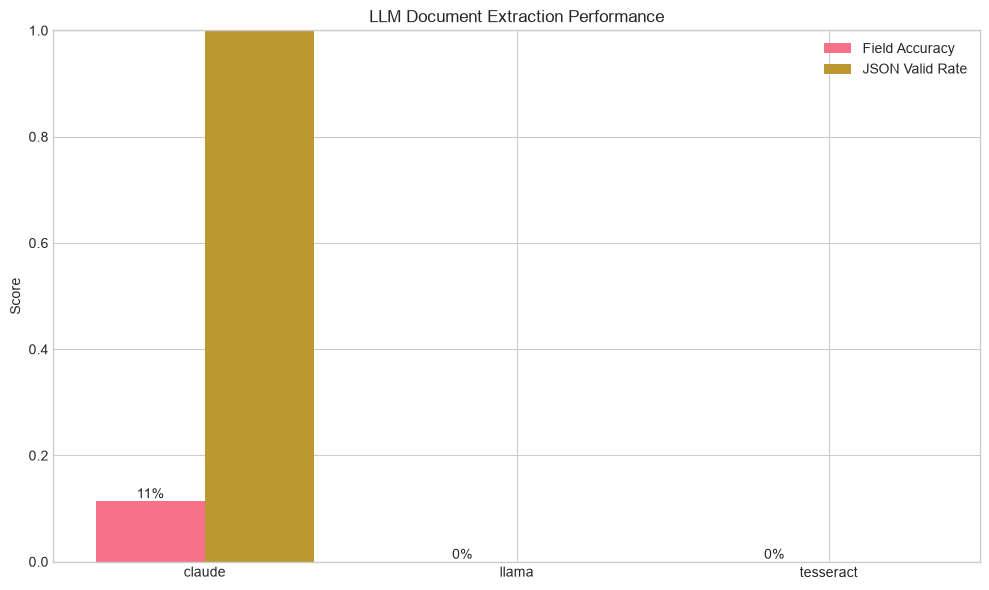

In [7]:
# Chart 1: Model Comparison
if not df_extract.empty and df_extract["model"].nunique() > 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    summary = df_extract.groupby("model").agg({
        "field_accuracy": "mean",
        "json_valid": "mean",
    }).round(3)
    
    x = np.arange(len(summary))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, summary["field_accuracy"], width, label="Field Accuracy")
    bars2 = ax.bar(x + width/2, summary["json_valid"], width, label="JSON Valid Rate")
    
    ax.set_ylabel("Score")
    ax.set_title("LLM Document Extraction Performance")
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index)
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.0%}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig("../results/chart_model_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
# Chart 2: Chaos Tolerance Curve
if chaos_results:
    df_chaos = pd.DataFrame(chaos_results)
    
    if df_chaos["accuracy"].notna().any():
        fig, ax = plt.subplots(figsize=(10, 6))
        
        accuracy_by_level = df_chaos.groupby("chaos_level")["accuracy"].agg(["mean", "std"])
        
        ax.plot(accuracy_by_level.index, accuracy_by_level["mean"], 
                marker='o', linewidth=2, markersize=10, color='#2ecc71')
        ax.fill_between(accuracy_by_level.index, 
                        accuracy_by_level["mean"] - accuracy_by_level["std"],
                        accuracy_by_level["mean"] + accuracy_by_level["std"],
                        alpha=0.2, color='#2ecc71')
        
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
        
        ax.set_xlabel("Chaos Level (0 = clean, 5 = heavily degraded)", fontsize=12)
        ax.set_ylabel("Extraction Accuracy", fontsize=12)
        ax.set_title("How Accuracy Degrades with Document Quality", fontsize=14)
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig("../results/chart_chaos_tolerance.png", dpi=300, bbox_inches='tight')
        plt.show()

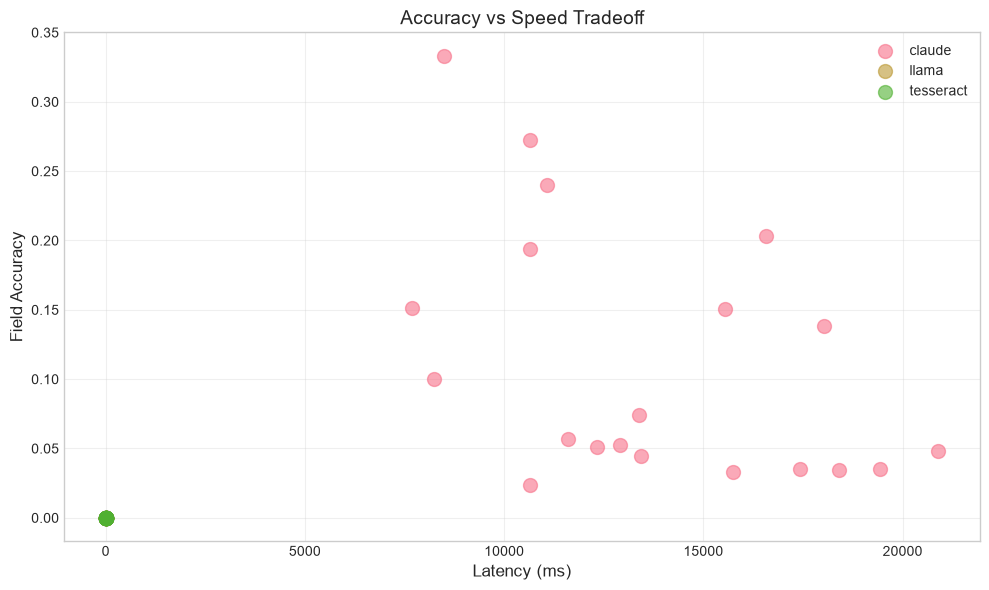

In [9]:
# Chart 3: Accuracy vs Latency tradeoff
if not df_extract.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for model in df_extract["model"].unique():
        model_data = df_extract[df_extract["model"] == model]
        ax.scatter(model_data["latency_ms"], model_data["field_accuracy"], 
                   label=model, alpha=0.6, s=100)
    
    ax.set_xlabel("Latency (ms)", fontsize=12)
    ax.set_ylabel("Field Accuracy", fontsize=12)
    ax.set_title("Accuracy vs Speed Tradeoff", fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("../results/chart_accuracy_latency.png", dpi=300, bbox_inches='tight')
    plt.show()

## Article-Ready Findings

In [10]:
# Generate article findings summary
findings = []

if not df_extract.empty:
    # Finding 1: Overall accuracy
    avg_acc = df_extract["field_accuracy"].mean()
    findings.append(f"Overall field extraction accuracy: {avg_acc:.1%}")
    
    # Finding 2: Best model
    best_model = df_extract.groupby("model")["field_accuracy"].mean().idxmax()
    best_acc = df_extract.groupby("model")["field_accuracy"].mean().max()
    findings.append(f"Best performing model: {best_model} at {best_acc:.1%} accuracy")
    
    # Finding 3: JSON validity
    json_rate = df_extract["json_valid"].mean()
    findings.append(f"JSON output validity rate: {json_rate:.1%}")
    
    # Finding 4: Hallucinations
    total_halluc = df_extract["hallucinations"].sum()
    halluc_rate = (df_extract["hallucinations"] > 0).mean()
    findings.append(f"Documents with hallucinations: {halluc_rate:.1%} ({total_halluc} total instances)")

if chaos_results:
    df_chaos = pd.DataFrame(chaos_results)
    if df_chaos["accuracy"].notna().any():
        # Finding 5: Chaos threshold
        accuracy_by_level = df_chaos.groupby("chaos_level")["accuracy"].mean()
        drop_50 = accuracy_by_level[accuracy_by_level < 0.5].index.min()
        if pd.notna(drop_50):
            findings.append(f"Chaos threshold: Accuracy drops below 50% at level {drop_50}")
        else:
            findings.append("Chaos threshold: Model maintains >50% accuracy across all chaos levels")

print("=" * 60)
print("ARTICLE-READY FINDINGS")
print("=" * 60)
for i, f in enumerate(findings, 1):
    print(f"{i}. {f}")

ARTICLE-READY FINDINGS
1. Overall field extraction accuracy: 3.8%
2. Best performing model: claude at 11.4% accuracy
3. JSON output validity rate: 33.3%
4. Documents with hallucinations: 33.3% (245 total instances)


## Export for Article

In [11]:
# Save findings to markdown
findings_md = "# Experiment Findings\n\n"
findings_md += "Generated from chaos-eval experiments.\n\n"

findings_md += "## Key Statistics\n\n"
for f in findings:
    findings_md += f"- {f}\n"

findings_md += "\n## Charts\n\n"
findings_md += "- `chart_model_comparison.png` - Model performance comparison\n"
findings_md += "- `chart_chaos_tolerance.png` - Accuracy degradation curve\n"
findings_md += "- `chart_accuracy_latency.png` - Speed vs accuracy tradeoff\n"

with open("../results/findings.md", "w") as f:
    f.write(findings_md)

print("Findings exported to results/findings.md")

Findings exported to results/findings.md


In [12]:
# List all generated artifacts
print("\n📁 Generated Artifacts:")
for f in sorted(RESULTS_DIR.glob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024
        print(f"   {f.name} ({size:.1f} KB)")


📁 Generated Artifacts:
   .gitkeep (0.1 KB)
   chaos_gradient_visual.png (2520.4 KB)
   chart_accuracy_latency.png (137.1 KB)
   chart_model_comparison.png (75.8 KB)
   experiment_20260127_113526.json (28.0 KB)
   experiment_20260617_204521.json (28.0 KB)
   experiment_20260618_221846.json (209.5 KB)
   findings.md (0.5 KB)
   model_comparison.png (52.3 KB)
   noise_types.png (2041.7 KB)
